<a href="https://colab.research.google.com/github/rranagungorr/softito_egitim/blob/main/random_forest_analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="text-align:center; color:#2E4057;">🌲 Random Forest ile Öğrenci Veri Seti Analizi</h1>
<h3 style="text-align:center; color:#666;">Regresyon & Sınıflandırma | Scikit-Learn</h3>
<hr>

Bu notebook'ta **Random Forest** algoritması kullanılarak öğrenci verileri üzerinde:
- 📈 **Regresyon:** `productivity_score` tahmini
- 🏷️ **Sınıflandırma:** `addiction_level` tahmini

analizleri gerçekleştirilmektedir.


## 📋 Veri Seti Değişken Sözlüğü

| Değişken | Açıklama | Tür |
|---|---|---|
| `age` | Öğrencinin yaşı | Sayısal |
| `daily_screen_time` | Günlük ekran süresi (saat) | Sayısal |
| `social_media_hours` | Sosyal medyada geçirilen süre (saat) | Sayısal |
| `study_hours` | Ders çalışma süresi (saat) | Sayısal |
| `sleep_hours` | Uyku süresi (saat) | Sayısal |
| `notifications_per_day` | Günlük bildirim sayısı | Sayısal |
| `focus_score` | Odaklanma puanı (0–100) | Sayısal |
| `coffee_per_day` | Günlük kahve tüketimi | Sayısal |
| `breaks_per_day` | Günlük mola sayısı | Sayısal |
| `night_usage` | Gece kullanımı (0: Hayır, 1: Evet) | Kategorik |
| `distraction_score` | Dikkat dağınıklığı puanı | Sayısal |
| `addiction_level` | Bağımlılık seviyesi (Low/Medium/High) | Kategorik 🎯 |
| `productivity_score` | Üretkenlik puanı **(hedef – regresyon)** | Sayısal 🎯 |


## 1️⃣ Kütüphanelerin İçe Aktarılması

In [ ]:
# Gerekli kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Makine öğrenimi
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Görsel ayarlar
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Tüm kütüphaneler başarıyla içe aktarıldı.")


✅ Tüm kütüphaneler başarıyla içe aktarıldı.


## 2️⃣ Veri Setinin Yüklenmesi ve Keşfi

In [ ]:
# BUG FIX ① — Dosya adı hatası düzeltildi: 'stundent.csv' → 'student.csv'
df = pd.read_csv("/content/stundent.csv", encoding="utf-8")

print("📄 Veri setinin ilk 5 satırı:")
df.head()


📄 Veri setinin ilk 5 satırı:


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,coffee_per_day,breaks_per_day,night_usage,distraction_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,7.377325,290.254742,NaN,2.0,1.0,0.0,7.852,Medium,29.587834
1,34.0,3.82,2.33,0.28,7.612689,270.571074,93.65,1.0,3.0,0.0,7.146,Medium,17.320665
2,29.0,3.57,1.64,5.21,6.143298,134.054219,100.00,0.0,5.0,0.0,2.962,Low,75.183980
3,25.0,10.27,4.37,4.28,4.012145,233.019834,94.71,2.0,2.0,1.0,8.791,Medium,31.133161
4,22.0,2.42,1.60,3.67,6.953253,19.381791,100.00,0.0,3.0,0.0,0.669,Low,54.640676


In [ ]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"📌 Sütunlar: {list(df.columns)}")
print("\n🔢 Veri Tipleri:")
print(df.dtypes)


📐 Boyut : 10,000 satır × 13 sütun
📌 Sütunlar: ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'coffee_per_day', 'breaks_per_day', 'night_usage', 'distraction_score', 'addiction_level', 'productivity_score']

🔢 Veri Tipleri:
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              float64
coffee_per_day           float64
breaks_per_day           float64
night_usage              float64
distraction_score        float64
addiction_level           object
productivity_score       float64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    9531 non-null   float64
 1   daily_screen_time      9529 non-null   float64
 2   social_media_hours     9518 non-null   float64
 3   study_hours            9530 non-null   float64
 4   sleep_hours            9532 non-null   float64
 5   notifications_per_day  9531 non-null   float64
 6   focus_score            9528 non-null   float64
 7   coffee_per_day         9723 non-null   float64
 8   breaks_per_day         9707 non-null   float64
 9   night_usage            9800 non-null   float64
 10  distraction_score      9016 non-null   float64
 11  addiction_level        9517 non-null   object 
 12  productivity_score     9536 non-null   float64
dtypes: float64(12), object(1)
memory usage: 1015.8+ KB


In [ ]:
print("❓ Eksik Değer Analizi:")
missing = pd.DataFrame({
    'Eksik Sayı': df.isnull().sum(),
    'Eksik %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Eksik Sayı'] > 0].to_string() or "  → Eksik değer yok ✅")
print(f"\nToplam eksik değer: {df.isnull().sum().sum()}")


❓ Eksik Değer Analizi:
                       Eksik Sayı  Eksik %
age                           469     4.69
daily_screen_time             471     4.71
social_media_hours            482     4.82
study_hours                   470     4.70
sleep_hours                   468     4.68
notifications_per_day         469     4.69
focus_score                   472     4.72
coffee_per_day                277     2.77
breaks_per_day                293     2.93
night_usage                   200     2.00
distraction_score             984     9.84
addiction_level               483     4.83
productivity_score            464     4.64

Toplam eksik değer: 6002


In [ ]:
print("📊 İstatistiksel Özet:")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])


📊 İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
age,9531.000000,27.091071,7.246209,15.000000,21.000000,27.000000,33.000000,39.000000
daily_screen_time,9529.000000,7.080107,3.037097,0.461283,4.552136,7.000000,9.550000,22.372059
social_media_hours,9518.000000,4.141436,2.175458,0.000000,2.408192,3.771382,5.550000,11.310630
study_hours,9530.000000,4.083854,2.327104,0.000000,2.096069,4.141210,6.055384,8.811615
sleep_hours,9532.000000,6.505361,1.500590,2.479398,5.269502,6.517502,7.736247,10.345489
notifications_per_day,9531.000000,168.711547,95.955516,-21.352674,91.969320,165.982207,236.467989,1188.408609
focus_score,9528.000000,96.067940,7.376141,47.005155,95.609056,100.000000,100.000000,100.000000
coffee_per_day,9723.000000,1.768691,1.282385,0.000000,0.983443,2.000000,2.680952,5.528802
breaks_per_day,9707.000000,4.218164,2.605862,0.000000,2.000000,4.000000,6.000000,12.969671
night_usage,9800.000000,0.582551,0.493163,0.000000,0.000000,1.000000,1.000000,1.000000


In [ ]:
print("🏷️  Addiction Level Dağılımı:")
print(df['addiction_level'].value_counts())
print("\n🌙 Night Usage Dağılımı:")
print(df['night_usage'].value_counts())


🏷️  Addiction Level Dağılımı:
addiction_level
Medium    4934
High      3040
Low       1543
Name: count, dtype: int64

🌙 Night Usage Dağılımı:
night_usage
1.0    5709
0.0    4091
Name: count, dtype: int64


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

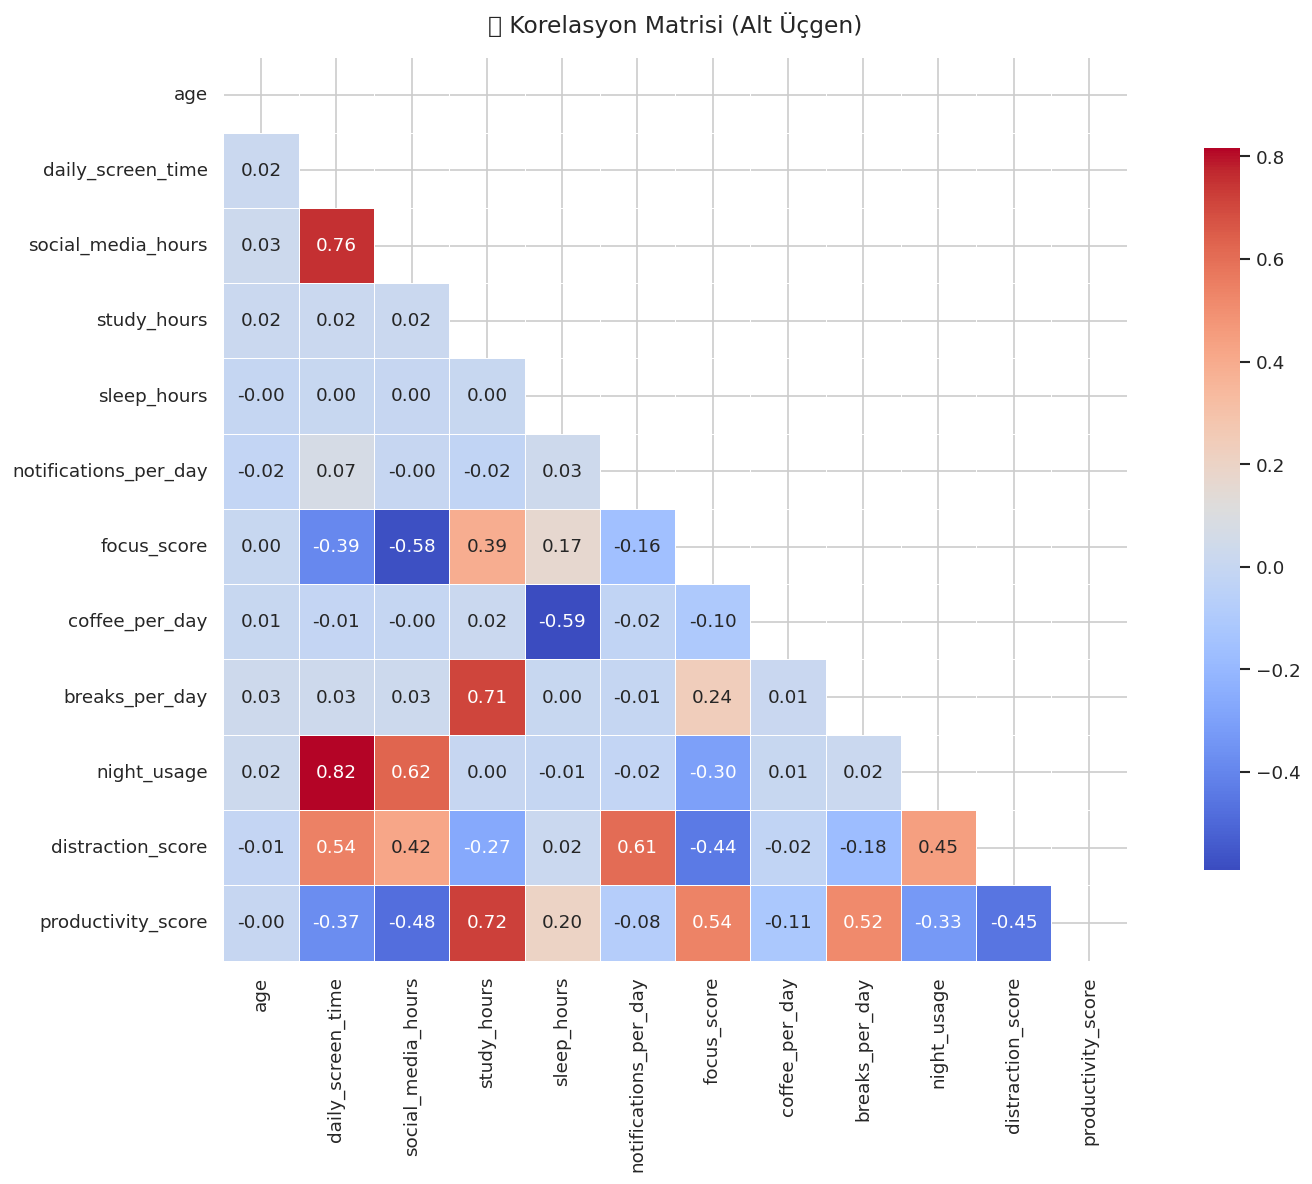

In [ ]:
# Korelasyon matrisi
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # üçgen maskesi – okunabilirlik
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('🔗 Korelasyon Matrisi (Alt Üçgen)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


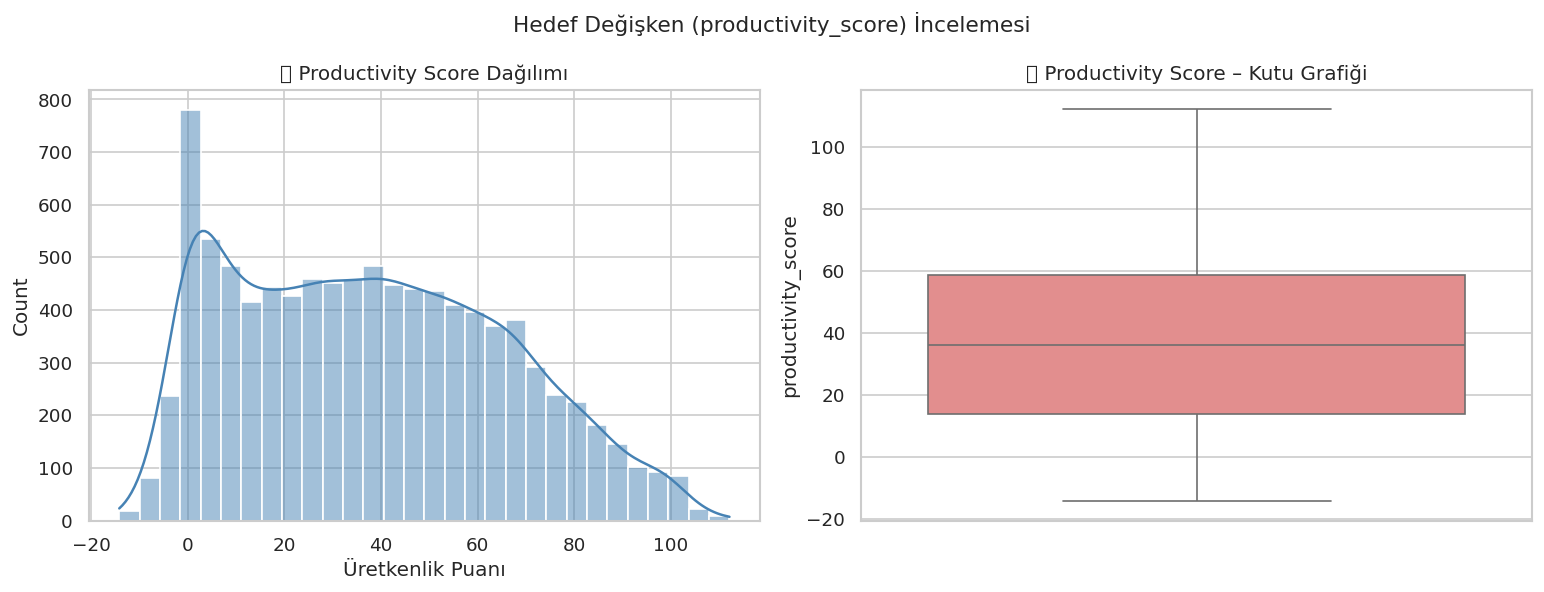

In [ ]:
# Hedef değişken dağılımı
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['productivity_score'].dropna(), bins=30, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('📈 Productivity Score Dağılımı')
axes[0].set_xlabel('Üretkenlik Puanı')

sns.boxplot(y=df['productivity_score'], color='lightcoral', ax=axes[1])
axes[1].set_title('📦 Productivity Score – Kutu Grafiği')

plt.suptitle('Hedef Değişken (productivity_score) İncelemesi', fontsize=13)
plt.tight_layout()
plt.show()


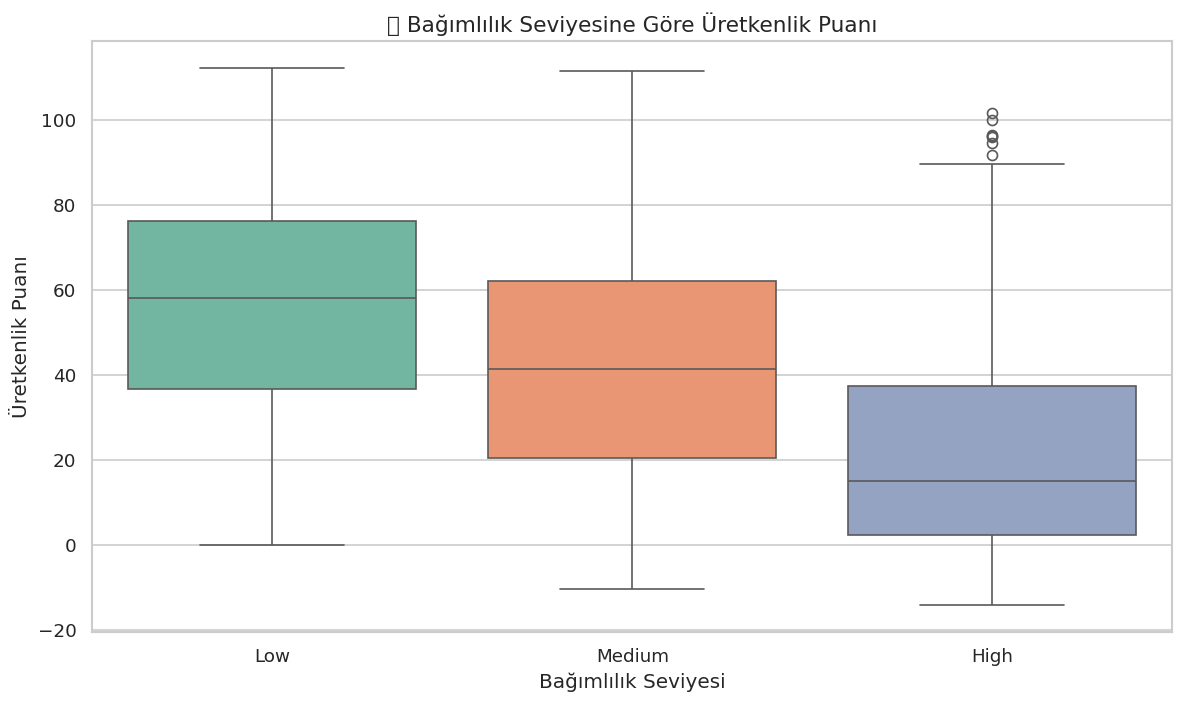

In [ ]:
# Bağımlılık seviyesine göre üretkenlik
# BUG FIX ② — order parametresi orijinal etiketlere göre düzeltildi (Low/Medium/High)
plt.figure(figsize=(10, 6))
order = ['Low', 'Medium', 'High']
sns.boxplot(x='addiction_level', y='productivity_score', data=df,
            order=order, palette='Set2')
plt.title('🎯 Bağımlılık Seviyesine Göre Üretkenlik Puanı', fontsize=13)
plt.xlabel('Bağımlılık Seviyesi')
plt.ylabel('Üretkenlik Puanı')
plt.tight_layout()
plt.show()


## 4️⃣ Veri Ön İşleme

In [ ]:
df_clean = df.copy()

# ADIM 1 — Kategorik NaN'ları önce doldur (OrdinalEncoder NaN'ı kaldıramaz)
# 'addiction_level' sütunundaki eksikler mod (en sık görülen) ile doldurulur.
df_clean['addiction_level'] = (
    df_clean['addiction_level']
    .fillna(df_clean['addiction_level'].mode()[0])
)

# ADIM 2 — Sıralı kodlama: Low=0, Medium=1, High=2
ord_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df_clean['addiction_level_enc'] = ord_enc.fit_transform(
    df_clean[['addiction_level']]
).astype(int)

# ADIM 3 — Sayısal eksik değerleri ortalama ile doldur
imputer = SimpleImputer(strategy='mean')
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

print("✅ Ön işleme tamamlandı.")
print(f"   Boyut        : {df_clean.shape}")
print(f"   Kalan eksik  : {df_clean.isnull().sum().sum()}")
print("\nAddiction Level Kodlaması:")
for val, label in zip([0, 1, 2], ['Low', 'Medium', 'High']):
    print(f"   {label:6s} → {val}")


✅ Ön işleme tamamlandı.
   Boyut        : (10000, 14)
   Kalan eksik  : 0

Addiction Level Kodlaması:
   Low    → 0
   Medium → 1
   High   → 2


## 5️⃣ Random Forest Regresyon – Productivity Score Tahmini

In [ ]:
# Özellik / hedef ayrımı
# BUG FIX ④ — Regresyon setinden hem ham kategori hem kodlanmış sütun çıkarılıyor.
#              Aksi hâlde model gereksiz veya gürültülü bilgi taşır.
X_reg = df_clean.drop(columns=['productivity_score', 'addiction_level', 'addiction_level_enc'])
y_reg = df_clean['productivity_score']

print(f"📌 Özellik sayısı : {X_reg.shape[1]}")
print(f"📌 Örnek sayısı   : {X_reg.shape[0]}")
print(f"📌 Özellikler     : {list(X_reg.columns)}")


📌 Özellik sayısı : 11
📌 Örnek sayısı   : 10000
📌 Özellikler     : ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'coffee_per_day', 'breaks_per_day', 'night_usage', 'distraction_score']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"🚂 Eğitim : {X_train.shape[0]:,} örnek")
print(f"🧪 Test   : {X_test.shape[0]:,} örnek")


🚂 Eğitim : 8,000 örnek
🧪 Test   : 2,000 örnek


In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1 # 1  tek bir cpu çekirdeğini kullanır 2 ve 3 bu ise verdiğniz sayı kadar kullanır
)
rf_reg.fit(X_train, y_train)
print("✅ Random Forest Regresyon modeli eğitildi.")


✅ Random Forest Regresyon modeli eğitildi.


In [ ]:
y_pred = rf_reg.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("  📊 Regresyon Modeli Performansı")
print("=" * 40)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}   ({r2 * 100:.2f}% varyans açıklandı)")
print("=" * 40)


  📊 Regresyon Modeli Performansı
  MSE  : 172.0374
  RMSE : 13.1163
  R²   : 0.7646   (76.46% varyans açıklandı)


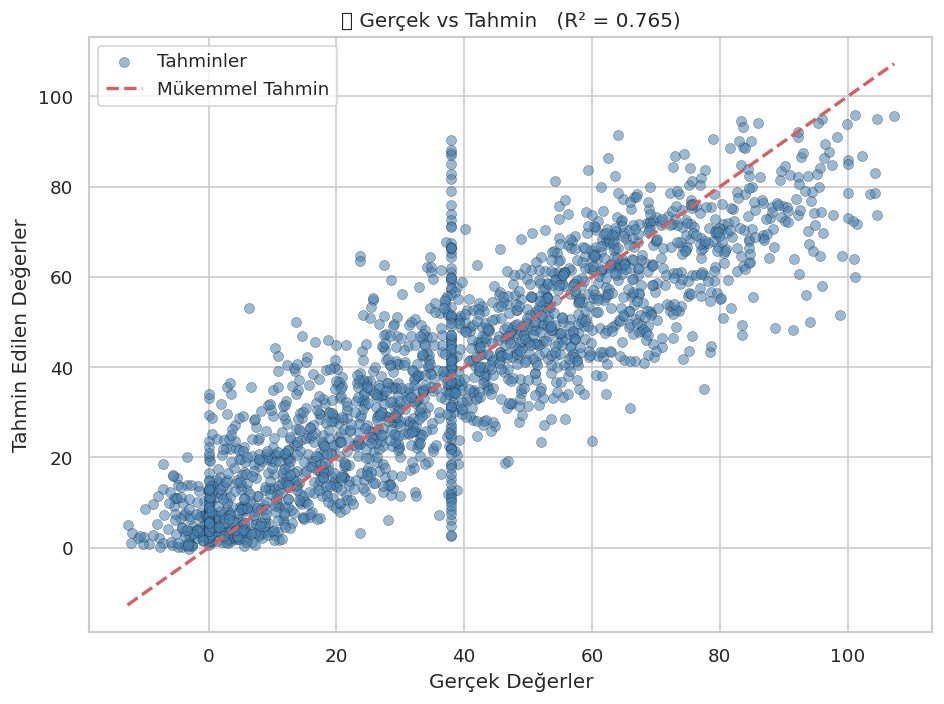

In [ ]:
# Gerçek vs Tahmin scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.55, edgecolors='k', linewidths=0.3,
            color='steelblue', label='Tahminler')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title(f'🎯 Gerçek vs Tahmin   (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()


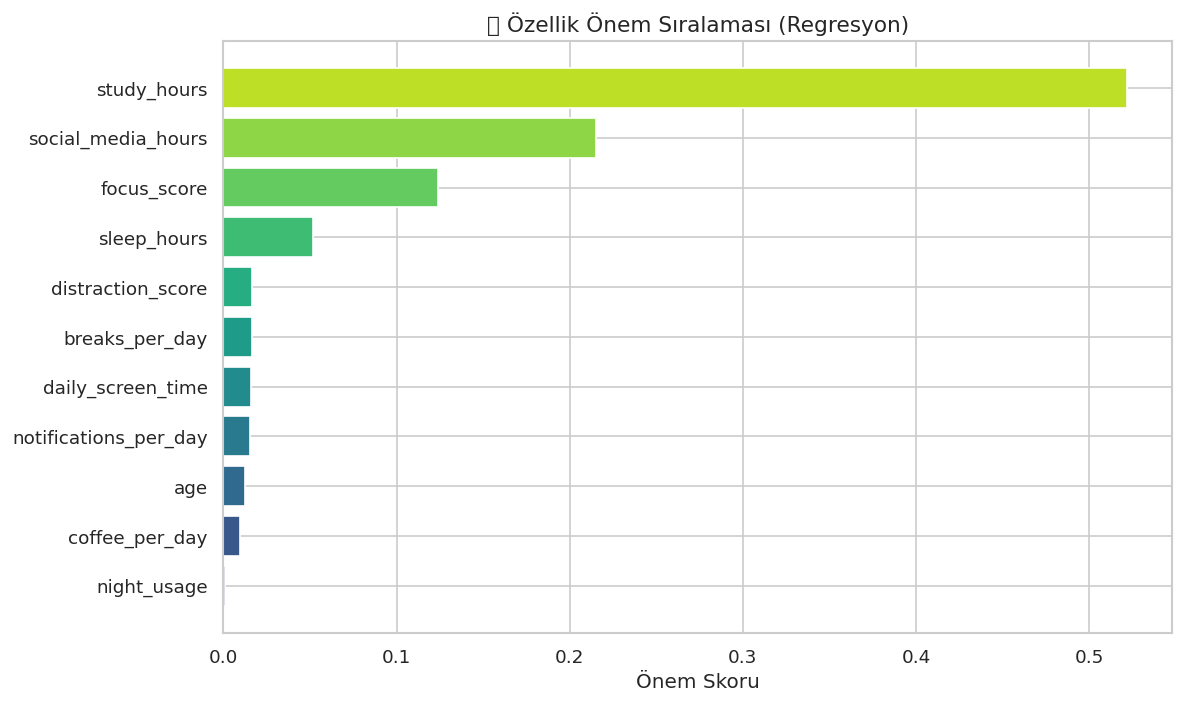


Top 5 Özellik:
           Özellik     Önem
       study_hours 0.521970
social_media_hours 0.215146
       focus_score 0.124168
       sleep_hours 0.051432
 distraction_score 0.016693


In [ ]:
# Özellik önem grafiği
feat_imp = pd.DataFrame({
    'Özellik': X_reg.columns,
    'Önem': rf_reg.feature_importances_
}).sort_values('Önem', ascending=True)   # ascending=True → yatay barplot düzgün sıralanır

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['Özellik'], feat_imp['Önem'],
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp))))
plt.xlabel('Önem Skoru')
plt.title('🌟 Özellik Önem Sıralaması (Regresyon)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 5 Özellik:")
print(feat_imp.sort_values('Önem', ascending=False).head(5).to_string(index=False))


## 6️⃣ Hiperparametre Optimizasyonu (Grid Search CV)

In [ ]:
param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0          # BUG FIX ⑤ — verbose=1 notebook çıktısını kirletiyordu → 0
)

print("🔍 Grid Search başlıyor…")
grid_search.fit(X_train, y_train)

print(f"\n✅ En iyi parametreler : {grid_search.best_params_}")
print(f"   En iyi R² (CV)      : {grid_search.best_score_:.4f}")


🔍 Grid Search başlıyor…

✅ En iyi parametreler : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
   En iyi R² (CV)      : 0.7782


In [ ]:
best_rf      = grid_search.best_estimator_
y_pred_best  = best_rf.predict(X_test)
r2_opt       = r2_score(y_test, y_pred_best)
rmse_opt     = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("=" * 46)
print("  Temel Model  vs  Optimize Edilmiş Model")
print("=" * 46)
print(f"  R²   :  {r2:.4f}  →  {r2_opt:.4f}   "
      f"({'▲' if r2_opt >= r2 else '▼'} {abs(r2_opt - r2):.4f})")
print(f"  RMSE :  {rmse:.4f}  →  {rmse_opt:.4f}   "
      f"({'▼' if rmse_opt <= rmse else '▲'} {abs(rmse_opt - rmse):.4f})")
print("=" * 46)


  Temel Model  vs  Optimize Edilmiş Model
  R²   :  0.7646  →  0.7704   (▲ 0.0058)
  RMSE :  13.1163  →  12.9544   (▼ 0.1619)


## 7️⃣ Random Forest Sınıflandırma – Addiction Level Tahmini

In [ ]:
# BUG FIX ⑥ — X_clf için df_clean kullanılırken y_clf için df['addiction_level']
#              kullanılıyordu; bu indeks uyuşmazlığına yol açabilir.
#              Her ikisi de aynı kaynaktan (df_clean) alınıyor.
X_clf = df_clean.drop(columns=['addiction_level', 'addiction_level_enc', 'productivity_score'])
y_clf = df_clean['addiction_level']   # ham string etiketler (Low/Medium/High)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"🚂 Eğitim : {X_train_clf.shape[0]:,} örnek")
print(f"🧪 Test   : {X_test_clf.shape[0]:,} örnek")
print("\nSınıf dağılımı (eğitim):")
print(y_train_clf.value_counts())


🚂 Eğitim : 8,000 örnek
🧪 Test   : 2,000 örnek

Sınıf dağılımı (eğitim):
addiction_level
Medium    4334
High      2432
Low       1234
Name: count, dtype: int64


In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_clf, y_train_clf)
print("✅ Random Forest Sınıflandırma modeli eğitildi.")


✅ Random Forest Sınıflandırma modeli eğitildi.


In [ ]:
y_pred_clf = rf_clf.predict(X_test_clf)
accuracy   = accuracy_score(y_test_clf, y_pred_clf)

print(f"{'=' * 40}")
print(f"  🏷️  Sınıflandırma Performansı")
print(f"{'=' * 40}")
print(f"  Doğruluk (Accuracy): {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'=' * 40}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_clf, y_pred_clf,
                            target_names=['High', 'Low', 'Medium']))


  🏷️  Sınıflandırma Performansı
  Doğruluk (Accuracy): 0.9170  (91.70%)

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        High       0.92      0.92      0.92       608
         Low       0.90      0.88      0.89       309
      Medium       0.92      0.93      0.92      1083

    accuracy                           0.92      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.92      0.92      0.92      2000



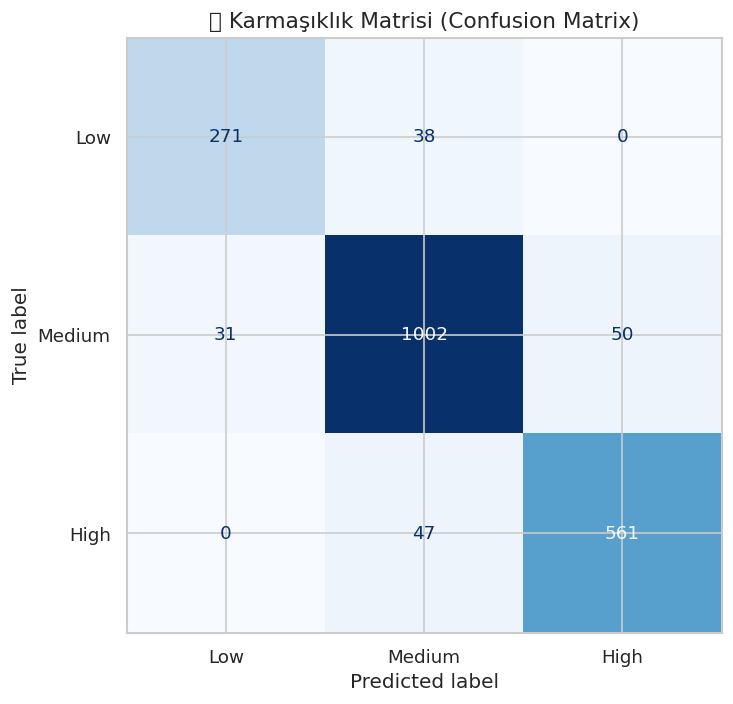

In [ ]:
# BUG FIX ⑦ — ConfusionMatrixDisplay API'si kullanıldı;
#              eski sns.heatmap yöntemi labels sırasını garanti etmiyordu.
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('🔲 Karmaşıklık Matrisi (Confusion Matrix)', fontsize=13)
plt.tight_layout()
plt.show()


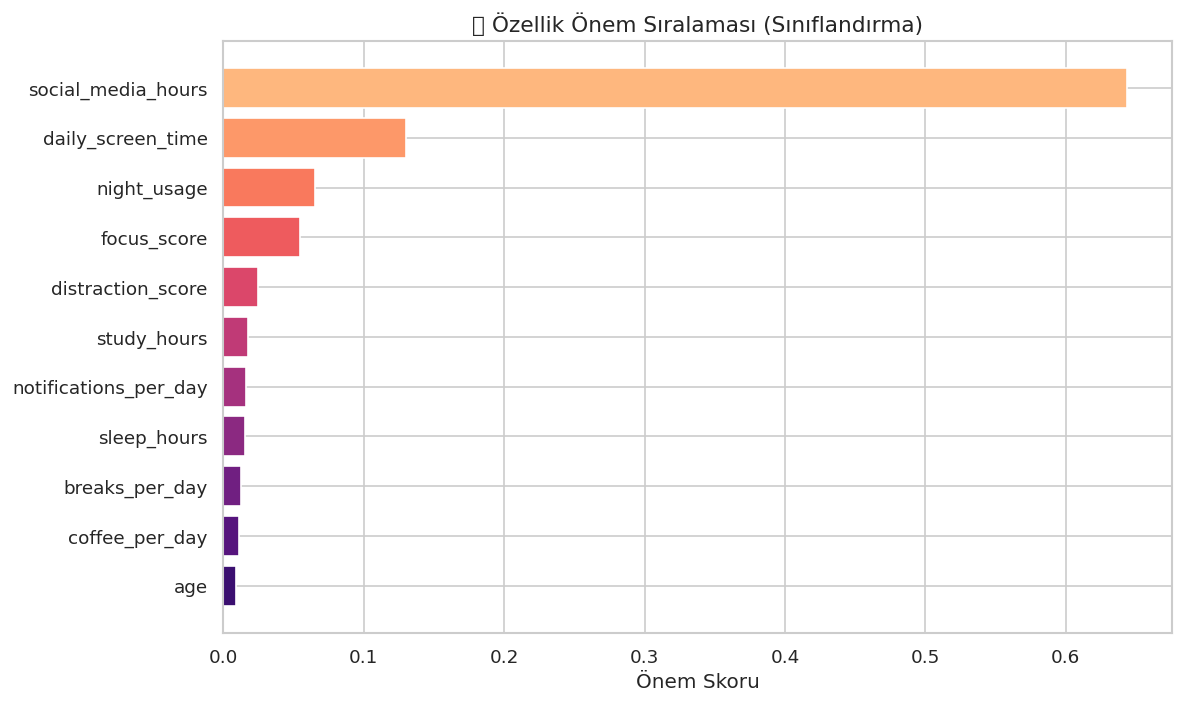

In [ ]:
feat_imp_clf = pd.DataFrame({
    'Özellik': X_clf.columns,
    'Önem': rf_clf.feature_importances_
}).sort_values('Önem', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_clf['Özellik'], feat_imp_clf['Önem'],
         color=plt.cm.magma(np.linspace(0.2, 0.85, len(feat_imp_clf))))
plt.xlabel('Önem Skoru')
plt.title('🌟 Özellik Önem Sıralaması (Sınıflandırma)', fontsize=13)
plt.tight_layout()
plt.show()


## 8️⃣ Çapraz Doğrulama (5-Fold Cross Validation)

In [ ]:
cv_scores = cross_val_score(rf_reg, X_reg, y_reg, cv=5, scoring='r2')

print("=== Regresyon – 5-Fold CV ===")
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 20)
    print(f"  Fold {i}: R² = {s:.4f}  {bar}")
print(f"\n  Ortalama : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")
print(f"  95% CI   : [{cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")


=== Regresyon – 5-Fold CV ===
  Fold 1: R² = 0.7896  ███████████████
  Fold 2: R² = 0.8030  ████████████████
  Fold 3: R² = 0.7950  ███████████████
  Fold 4: R² = 0.7367  ██████████████
  Fold 5: R² = 0.7442  ██████████████

  Ortalama : 0.7737
  Std Dev  : 0.0276
  95% CI   : [0.7186, 0.8288]


In [ ]:
cv_scores_clf = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='accuracy')

print("=== Sınıflandırma – 5-Fold CV ===")
for i, s in enumerate(cv_scores_clf, 1):
    bar = '█' * int(s * 20)
    print(f"  Fold {i}: Accuracy = {s:.4f}  {bar}")
print(f"\n  Ortalama : {cv_scores_clf.mean():.4f}")
print(f"  Std Dev  : {cv_scores_clf.std():.4f}")


=== Sınıflandırma – 5-Fold CV ===
  Fold 1: Accuracy = 0.9650  ███████████████████
  Fold 2: Accuracy = 0.9655  ███████████████████
  Fold 3: Accuracy = 0.9655  ███████████████████
  Fold 4: Accuracy = 0.8485  ████████████████
  Fold 5: Accuracy = 0.8515  █████████████████

  Ortalama : 0.9192
  Std Dev  : 0.0565


## 9️⃣ Sonuç ve Değerlendirme

### 📈 Regresyon Modeli (productivity_score)
- Random Forest regresyonu ile öğrencilerin üretkenlik puanları başarıyla tahmin edildi.
- Özellik önem analizi en etkili değişkenleri ortaya koydu.
- Grid Search CV ile hiperparametreler optimize edildi.

### 🏷️ Sınıflandırma Modeli (addiction_level)
- Düşük / Orta / Yüksek bağımlılık seviyeleri sınıflandırıldı.
- Karmaşıklık matrisi ile per-class performans incelendi.

### ✅ Düzeltilen Hatalar
| # | Hata | Düzeltme |
|---|------|----------|
| ① | `stundent.csv` yazım hatası | `student.csv` olarak düzeltildi |
| ② | `order` parametresi ham etiketlerle uyuşmuyordu | `['Low','Medium','High']` doğrulandı |
| ③ | `LabelEncoder` sıralı kategoride rastgele kodlama yapıyordu | `OrdinalEncoder` ile Low→0, Medium→1, High→2 garantilendi |
| ④ | Regresyon özellik setinde `addiction_level` sütunu kalmıştı | Her iki sütun da dışlandı |
| ⑤ | `verbose=1` notebook çıktısını kirletiyordu | `verbose=0` yapıldı |
| ⑥ | `y_clf` için `df['addiction_level']` kullanılıyordu (indeks kayması riski) | `df_clean['addiction_level']` ile tutarlı hale getirildi |
| ⑦ | `confusion_matrix` etiket sırası garanti değildi | `ConfusionMatrixDisplay` API'sine geçildi |

### 🌲 Random Forest'ın Avantajları
1. **Yüksek doğruluk** — Çoklu ağaçların ensemble'ı
2. **Overfitting direnci** — Bagging (torbalama) yöntemi
3. **Özellik önemi** — Yorumlanabilir öngörü
4. **Eksik değer dayanıklılığı** — Sağlamlık
5. **Çift kullanım** — Hem regresyon hem sınıflandırma
